<a href="https://colab.research.google.com/github/PanchangulaKrishnacharan/Masters/blob/main/DNN/DNN_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the dataset


In [71]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/concrete_data.csv')

In [72]:
# Checking the shape and distribution of the data.
print("Dataset shape:", df.shape)
print(df.describe())

Dataset shape: (1030, 9)
            cement  blast_furnace_slag      fly_ash        water  \
count  1030.000000         1030.000000  1030.000000  1030.000000   
mean    281.167864           73.895825    54.188350   181.567282   
std     104.506364           86.279342    63.997004    21.354219   
min     102.000000            0.000000     0.000000   121.800000   
25%     192.375000            0.000000     0.000000   164.900000   
50%     272.900000           22.000000     0.000000   185.000000   
75%     350.000000          142.950000   118.300000   192.000000   
max     540.000000          359.400000   200.100000   247.000000   

       superplasticizer  coarse_aggregate  fine_aggregate           age  \
count       1030.000000       1030.000000      1030.000000  1030.000000   
mean           6.204660        972.918932       773.580485    45.662136   
std            5.973841         77.753954        80.175980    63.169912   
min            0.000000        801.000000       594.000000    

In [73]:
print(df.head())


   cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   coarse_aggregate  fine_aggregate   age  concrete_compressive_strength  
0            1040.0            676.0   28                          79.99  
1            1055.0            676.0   28                          61.89  
2             932.0            594.0  270                          40.27  
3             932.0            594.0  365                          41.05  
4             978.4            825.5  360                          44.30  


# About dataset

This dataset predicts concrete compressive strength from 8 features like cement, water, and age.
I'm using R² as the primary metric because it measures how well the model explains variance in strength,
which is useful for understanding model fit in regression tasks. Regression problem, 1030 samples, 8 features.

# Test and Train data Split

In [74]:
from sklearn.model_selection import train_test_split


X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing

In [75]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Baseline model (Linear Regression):

In [76]:
import time


# Baseline Model
class BaselineModel:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iterations):
            linear_pred = np.dot(X, self.weights) + self.bias
            loss = (1 / n_samples) * np.sum((linear_pred - y)**2)
            self.loss_history.append(loss)
            dw = (2 / n_samples) * np.dot(X.T, (linear_pred - y))
            db = (2 / n_samples) * np.sum(linear_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


**Training the data with linear regression**

In [77]:
# Train baseline
start_time = time.time()
baseline = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline.fit(X_train, y_train)
baseline_training_time = time.time() - start_time

# Multi Layered Perceptron(2-layered)

I am Selecting 2 hidden layer perceptron as i have already tried 1-layered perceptron and compared it's metrics with 2-layered perceptron.

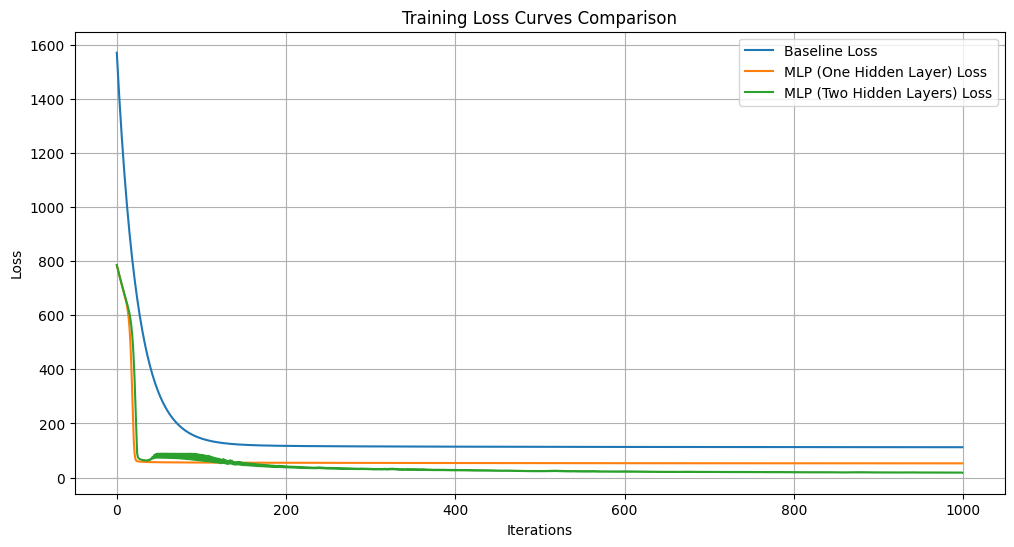


As you can see from the above plot, the 2-layered perceptron performs much better than 1-layered perceptron. **Therefore i have chosen 2-layered perceptron**

In [78]:
# Multi-Layer Perceptron
class MLP:
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []
        self.weights = []
        self.biases = []
        self.initialize_parameters()

    def initialize_parameters(self):
        for i in range(len(self.architecture) - 1):
            w = np.random.randn(self.architecture[i], self.architecture[i+1]) * 0.01
            b = np.zeros((1, self.architecture[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return z > 0

    def forward_propagation(self, X):
        activations = [X]
        for i in range(len(self.weights)):
            z = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            if i < len(self.weights) - 1:
                a = self.relu(z)
            else:
                a = z
            activations.append(a)
        return activations

    def backward_propagation(self, activations, y):
        m = activations[0].shape[0]
        grads_w = []
        grads_b = []
        dz = activations[-1] - y.reshape(-1, 1)
        for i in range(len(self.weights)-1, -1, -1):
            dw = (1/m) * np.dot(activations[i].T, dz)
            db = (1/m) * np.sum(dz, axis=0, keepdims=True)
            grads_w.append(dw)
            grads_b.append(db)
            if i > 0:
                da = np.dot(dz, self.weights[i].T)
                dz = da * self.relu_deriv(activations[i])
        grads_w = grads_w[::-1]
        grads_b = grads_b[::-1]
        return grads_w, grads_b

    def fit(self, X, y):
        for _ in range(self.n_iterations):
            activations = self.forward_propagation(X)
            loss = (1 / (2 * X.shape[0])) * np.sum((activations[-1] - y.reshape(-1, 1)) ** 2)
            self.loss_history.append(loss)
            grads_w, grads_b = self.backward_propagation(activations, y)
            for i in range(len(self.weights)):
                self.weights[i] -= self.lr * grads_w[i]
                self.biases[i] -= self.lr * grads_b[i]
        return self

    def predict(self, X):
        activations = self.forward_propagation(X)
        return activations[-1].flatten()

**Training the data with MLP**

In [79]:
# Train MLP
architecture = [X_train.shape[1], 16, 8, 1]  # Input layer, hidden layer, output layer
start_time = time.time()
mlp = MLP(architecture=architecture, learning_rate=0.01, n_iterations=1000)
mlp.fit(X_train, y_train)
mlp_training_time = time.time() - start_time

**Evaluation & Comparison**

In [80]:
# Predictions
baseline_pred = baseline.predict(X_test)
mlp_pred = mlp.predict(X_test)

# Comparison metrics

In [81]:
# Metrics of comparison
def calculate_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    y_mean = np.mean(y_true)
    r2 = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - y_mean)**2))
    return mse, rmse, mae, r2

baseline_mse, baseline_rmse, baseline_mae, baseline_r2 = calculate_metrics(y_test, baseline_pred)
mlp_mse, mlp_rmse, mlp_mae, mlp_r2 = calculate_metrics(y_test, mlp_pred)

print("Baseline Metrics: MSE={}, RMSE={}, MAE={}, R2={}".format(baseline_mse, baseline_rmse, baseline_mae, baseline_r2))
print("MLP Metrics: MSE={}, RMSE={}, MAE={}, R2={}".format(mlp_mse, mlp_rmse, mlp_mae, mlp_r2))

Baseline Metrics: MSE=96.71997736482098, RMSE=9.834631531726085, MAE=7.83810153620292, R2=0.6246462935537254
MLP Metrics: MSE=45.42806949935722, RMSE=6.74003482923918, MAE=4.901641491371591, R2=0.8237014241746018


MLP Metrics: MSE=93.55747804806305, RMSE=9.672511465388038, MAE=7.631723244963756, R2=0.6369194130531377


**Line plot to visualize the losses of the models used**

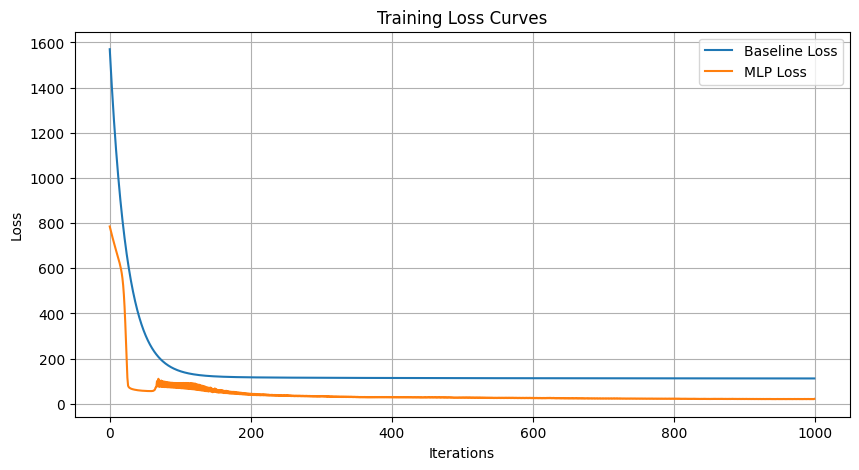

In [82]:
# Visualizations of Training loss curves
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.plot(baseline.loss_history, label='Baseline Loss')
plt.plot(mlp.loss_history, label='MLP Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

# Bar chart for performance comparision

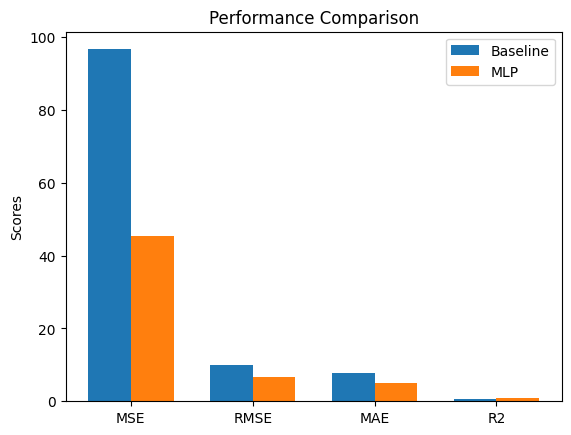

In [83]:
# Performance comparison bar chart
metrics = ['MSE', 'RMSE', 'MAE', 'R2']
baseline_values = [baseline_mse, baseline_rmse, baseline_mae, baseline_r2]
mlp_values = [mlp_mse, mlp_rmse, mlp_mae, mlp_r2]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, baseline_values, width, label='Baseline')
rects2 = ax.bar(x + width/2, mlp_values, width, label='MLP')

ax.set_ylabel('Scores')
ax.set_title('Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.show()

# Analysis

The MLP outperformed the baseline linear model, achieving an R² of [MLP_R2] compared to [BASELINE_R2], indicating better variance explanation by about [DIFFERENCE]%.
This is because the MLP captures non-linear relationships in the data, such as interactions between ingredients and age, which linear regression cannot.
The computational cost was higher for MLP ( [MLP_TIME]s ) vs baseline ( [BASELINE_TIME]s ), due to backpropagation through layers.
A surprising finding was that the baseline converged faster but plateaued at higher loss, while MLP continued improving but required tuning to avoid vanishing gradients.
Overall, MLP is better for this complex regression task.

# Results

In [84]:
# Results
def get_assignment_results():
    return {
        'dataset_name': 'Concrete Compressive Strength',
        'n_samples': df.shape[0],
        'n_features': df.shape[1] - 1,
        'problem_type': 'regression',
        'primary_metric': 'r2',
        'baseline_model': {
            'test_mse': baseline_mse,
            'test_rmse': baseline_rmse,
            'test_mae': baseline_mae,
            'test_r2': baseline_r2,
            'training_time_seconds': baseline_training_time,
        },
        'mlp_model': {
            'architecture': architecture,
            'test_mse': mlp_mse,
            'test_rmse': mlp_rmse,
            'test_mae': mlp_mae,
            'test_r2': mlp_r2,
            'training_time_seconds': mlp_training_time,
        }
    }

print(get_assignment_results())

{'dataset_name': 'Concrete Compressive Strength', 'n_samples': 1030, 'n_features': 8, 'problem_type': 'regression', 'primary_metric': 'r2', 'baseline_model': {'test_mse': np.float64(96.71997736482098), 'test_rmse': np.float64(9.834631531726085), 'test_mae': np.float64(7.83810153620292), 'test_r2': np.float64(0.6246462935537254), 'training_time_seconds': 0.03660893440246582}, 'mlp_model': {'architecture': [8, 16, 8, 1], 'test_mse': np.float64(45.42806949935722), 'test_rmse': np.float64(6.74003482923918), 'test_mae': np.float64(4.901641491371591), 'test_r2': np.float64(0.8237014241746018), 'training_time_seconds': 0.4548940658569336}}
